Modularising the actual LIDAR loading functions

In the previous notebook, I set up functions to figure out the bounding box/tile names etc. of a specific park.

In this one, I'm setting up the functions to actually load in the LiDAR and do the analysis.

Generally taking the approach in notebooks/version_2_lidar_analysis/02_May_2026_hexgrid.ipynb, but with new hexgrid functions.


In [1]:
# Import required libraries
import laspy
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.interpolate import griddata
from scipy.ndimage import generic_filter
import pdal
import json
from pathlib import Path
import datetime

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile

import glob
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union

In [2]:
# for dev work

import sys
import importlib

# Add src to path (do this once at the top)
sys.path.insert(0, '../../src')

# Initial import
import park_vga

# After editing:
importlib.reload(park_vga.defining_grids)
importlib.reload(park_vga.lidar)
importlib.reload(park_vga)
importlib.reload(park_vga)

<module 'park_vga' from '/Users/maeve/Documents/park-vga/notebooks/modularising_the_approach/../../src/park_vga/__init__.py'>

In [3]:
# example parks for analysis: two different datasets

boundaries_file = "../../example_datasets/Leeds_pp_or_g_cmb.geojson"
park_1 = "Woodhouse Moor"
park_2 = "LEEDS_24c20c1a69e8;LEEDS_26c1e2aa11e8"

buffer_distance = 20 # metres, buffer around park

lidar_dtm = "/Volumes/Extreme SSD/DTM"
lidar_dsm = "/Volumes/Extreme SSD/FZ_DSM"


In [4]:
park1_gdf = park_vga.load_data(boundaries_file, park_1, buffer_distance)
park2_gdf = park_vga.load_data(boundaries_file, park_2, buffer_distance, type="id")

First, check that the file exists: can you find it in the dataset?

In [5]:
park1_files = park_vga.park_geometry_to_file_path(park1_gdf, lidar_dtm, lidar_dsm)

In [6]:
print(type(park1_files))
print(park1_files)
print(len(park1_files))

<class 'tuple'>
(['/Volumes/Extreme SSD/DTM/SE23se_DTM_2m.tif', '/Volumes/Extreme SSD/DTM/SE23ne_DTM_2m.tif'], ['/Volumes/Extreme SSD/FZ_DSM/SE23se_FZ_DSM_2m.tif', '/Volumes/Extreme SSD/FZ_DSM/SE23ne_FZ_DSM_2m.tif'])
2


In [7]:
# for scaling up: need some form of *stop* if no lidar found.

if park1_files == ([], []):
    print("No files found for park 1")
else:
    print("Files found for park 1")

if park1_files[0] == [] and park1_files[1] == []:
    print("No files found for park 1")
else:
    print("Files found for park 1") 

Files found for park 1
Files found for park 1


In [8]:
park2_files= park_vga.park_geometry_to_file_path(park2_gdf, lidar_dtm, lidar_dsm)

In [9]:
park2_files

(['/Volumes/Extreme SSD/DTM/SE32nw_DTM_2m.tif'],
 ['/Volumes/Extreme SSD/FZ_DSM/SE32nw_FZ_DSM_2m.tif'])

Will do the examples step by step (e.g. park 1 first) and then park 2

In [10]:
park1_files

(['/Volumes/Extreme SSD/DTM/SE23se_DTM_2m.tif',
  '/Volumes/Extreme SSD/DTM/SE23ne_DTM_2m.tif'],
 ['/Volumes/Extreme SSD/FZ_DSM/SE23se_FZ_DSM_2m.tif',
  '/Volumes/Extreme SSD/FZ_DSM/SE23ne_FZ_DSM_2m.tif'])

In [11]:
from shapely.geometry import Point, LineString, Polygon, MultiPolygon, box

In [12]:
lidar_data = park_vga.load_lidar_rasters_for_park(
    park1_gdf, 
    park1_files[0],  # dtm_paths
    park1_files[1]   # dsm_paths
)


Loading 2 DSM and 2 DTM files
DSM valid pixels: 12500000 of 12500000 (100.0%)
DTM valid pixels: 12500000 of 12500000 (100.0%)
Output shape: (370, 301), Height range: -0.1m to 22.3m


In [13]:
lidar_data.keys()

dict_keys(['dsm', 'dtm', 'height_above_ground', 'dsm_meta', 'dtm_meta', 'transform', 'crs'])

In [14]:
lidar_data['transform']

Affine(2.0, 0.0, 428674.0,
       0.0, -2.0, 435444.0)

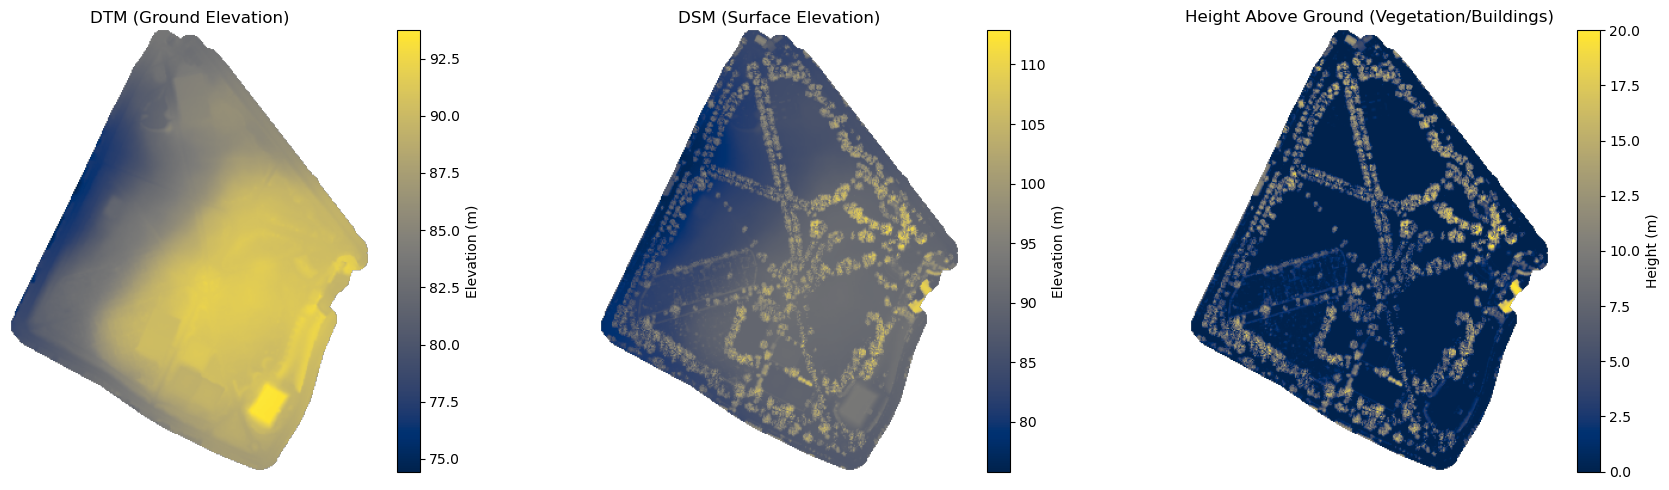

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DTM
im1 = axes[0].imshow(lidar_data['dtm'], cmap='cividis', origin='upper')
axes[0].set_title('DTM (Ground Elevation)')
plt.colorbar(im1, ax=axes[0], label='Elevation (m)')
axes[0].axis('off')

# DSM
im2 = axes[1].imshow(lidar_data['dsm'], cmap='cividis', origin='upper')
axes[1].set_title('DSM (Surface Elevation)')
plt.colorbar(im2, ax=axes[1], label='Elevation (m)')
axes[1].axis('off')

# Height above ground
im3 = axes[2].imshow(lidar_data['height_above_ground'], 
                     cmap='cividis', origin='upper', vmin=0, vmax=20)
axes[2].set_title('Height Above Ground (Vegetation/Buildings)')
plt.colorbar(im3, ax=axes[2], label='Height (m)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [16]:
hex_grid = park_vga.create_hexagon_grid(park1_gdf, spacing=10, return_mode='both')

Created 2349 pointy-top hexagons (10m vertical spacing)


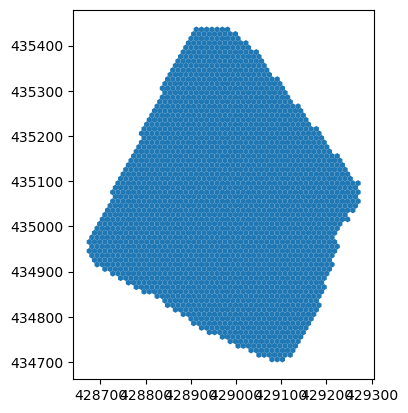

In [17]:
park_vga.check_plot(hex_grid["polygons"])

In [18]:
def point_to_raster_index(point, transform):
    """Convert a point to raster row/col indices"""
    from rasterio.transform import rowcol
    row, col = rowcol(transform, point.x, point.y)
    return int(row), int(col)

def get_elevation_at_point(point, raster, transform):
    """Get elevation value at a point from raster"""
    row, col = point_to_raster_index(point, transform)
    
    # Check bounds
    if 0 <= row < raster.shape[0] and 0 <= col < raster.shape[1]:
        return raster[row, col]
    return np.nan

In [19]:
def check_line_of_sight(observer_point, target_point, dsm, dtm, transform, 
                        observer_height=1.0, target_height=0):
    """
    Check if there is line of sight between two points
    
    Parameters:
    observer_point: Point geometry of observer
    target_point: Point geometry of target
    dsm: Digital Surface Model array
    dtm: Digital Terrain Model array  
    transform: rasterio transform
    observer_height: height of observer above ground (meters)
    target_height: height of target above ground (meters)
    
    Returns:
    bool: True if visible, False if blocked
    """
    # Get observer and target elevations
    obs_ground = get_elevation_at_point(observer_point, dtm, transform)
    target_ground = get_elevation_at_point(target_point, dtm, transform)
    
    if np.isnan(obs_ground) or np.isnan(target_ground):
        return False
    
    obs_elevation = obs_ground + observer_height
    target_elevation = target_ground + target_height
    
    # Calculate distance and number of sample points
    distance = observer_point.distance(target_point)
    
    if distance < 1:
        return True
    
    # Sample points along the line (every meter)
    num_samples = int(distance) + 1
    
    # Create line samples
    x_samples = np.linspace(observer_point.x, target_point.x, num_samples)
    y_samples = np.linspace(observer_point.y, target_point.y, num_samples)
    
    # Required height at each sample point (linear interpolation)
    required_heights = np.linspace(obs_elevation, target_elevation, num_samples)
    
    # Check each sample point
    for i in range(1, num_samples - 1):  # Skip start and end points
        sample_point = Point(x_samples[i], y_samples[i])
        
        # Get surface elevation at this point
        surface_elevation = get_elevation_at_point(sample_point, dsm, transform)
        
        if np.isnan(surface_elevation):
            continue
        
        # Check if surface blocks the line of sight
        if surface_elevation > required_heights[i]:
            return False
    
    return True

In [20]:
def calculate_visibility_metrics(analysis_points, dsm, dtm, transform, 
                                 observer_height=1.0, target_height=0, max_distance=100):
    """
    Calculate visibility metrics for all analysis points
    
    Parameters:
    analysis_points: GeoDataFrame of analysis points
    dsm: Digital Surface Model
    dtm: Digital Terrain Model
    transform: rasterio transform
    observer_height: observer eye height in meters; default 1 m
    max_distance: maximum visibility distance in meters
    
    Returns:
    GeoDataFrame with visibility metrics
    """
    print(f"Calculating visibility for {len(analysis_points)} points")
    
    results = []
    
    for idx, observer_row in analysis_points.iterrows():
        if idx % 50 == 0:
            print(f"Processing point {idx+1}/{len(analysis_points)}")
        
        observer_point = observer_row.geometry
        visible_count = 0
        total_checked = 0
        
        # Check visibility to all other points within max_distance
        for target_idx, target_row in analysis_points.iterrows():
            if idx == target_idx:
                continue
            
            target_point = target_row.geometry
            distance = observer_point.distance(target_point)
            
            if distance > max_distance:
                continue
            
            total_checked += 1
            
            if check_line_of_sight(observer_point, target_point, dsm, dtm, 
                                  transform, observer_height, target_height):
                visible_count += 1
        
        # Calculate visibility percentage
        if total_checked > 0:
            visibility_pct = (visible_count / total_checked) * 100
        else:
            visibility_pct = 0
        
        results.append({
            'geometry': observer_point,
            'visible_points': visible_count,
            'total_points': total_checked,
            'visibility_pct': visibility_pct
        })
    
    results_gdf = gpd.GeoDataFrame(results, crs=analysis_points.crs)

    
    return results_gdf

In [21]:
# visibility_results_1 = calculate_visibility_metrics(
#     hex_grid["centroids"], 
#     lidar_data['dsm'], 
#     lidar_data['dtm'], 
#     lidar_data['transform'],
#     observer_height=1.0,
#     target_height=0,
#     max_distance=100
# )

Time taken for this version: 5 mins, 6.8 seconds

In [22]:
# visibility_results_1.plot(column='visibility_pct', cmap="cividis")

In [23]:
# hex_grid["centroids"]

In [24]:
# hex_grid["polygons"]

In [25]:
# visibility_results_1

In [26]:
# # Rename current geometry column to 'centroids' and set polygon geometry
# visibility_results_1['centroids'] = visibility_results_1.geometry
# visibility_results_1 = visibility_results_1.set_geometry(hex_grid["polygons"].geometry)

In [27]:
# fig, ax = plt.subplots(figsize=(12, 10))
# visibility_results_1.plot(column='visibility_pct', 
#                           cmap='cividis', 
#                           ax=ax,
#                           legend=True,
#                           edgecolor='k',
#                           linewidth=0.5,
#                           legend_kwds={'label': 'Visibility %', 'shrink': 0.8})
# ax.set_title('Visibility Percentage by Hexagon')
# ax.axis('off')
# plt.tight_layout()
# plt.show()

In [28]:
# import matplotlib.colors as mcolors

# # Find the actual max visibility value
# max_visibility = visibility_results_1['visibility_pct'].max()

# # Round up to nearest 10% for bin edge
# max_bin_edge = int(np.ceil(max_visibility / 10) * 10)

# # Create bins from 0 to max_bin_edge
# bins = np.arange(0, max_bin_edge + 10, 10)

# # Create bin labels with actual numerical ranges
# bin_labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]

# # Bin the visibility percentages
# visibility_results_1['visibility_bin'] = pd.cut(visibility_results_1['visibility_pct'], 
#                                                  bins=bins, 
#                                                  labels=bin_labels,
#                                                  include_lowest=True)

# # Convert to numeric for plotting - use bin index instead of trying to convert strings
# visibility_results_1['visibility_bin_numeric'] = visibility_results_1['visibility_bin'].cat.codes + 1

# # Create discrete colormap with number of bins
# n_bins = len(bin_labels)
# cmap = plt.cm.get_cmap('cividis', n_bins)

# # Plot with discrete colors
# fig, ax = plt.subplots(figsize=(12, 10))
# visibility_results_1.plot(column='visibility_bin_numeric', 
#                           cmap=cmap, 
#                           ax=ax,
#                           legend=True,
#                           edgecolor='k',
#                           linewidth=0.5,
#                           vmin=0.5,
#                           vmax=n_bins + 0.5,
#                           legend_kwds={'label': 'Visibility % Range', 'shrink': 0.8})
# ax.set_title(f'Visibility Percentage by Hexagon (Max: {max_visibility:.1f}%)')
# ax.axis('off')
# plt.tight_layout()
# plt.show()

In [29]:
# fig, ax = plt.subplots(figsize=(12, 10))
# visibility_results_1.plot(column='visibility_bin_numeric', 
#                           cmap=cmap, 
#                           ax=ax,
#                           legend=False,  # Turn off default legend
#                           edgecolor='k',
#                           linewidth=0.5,
#                           vmin=0.5,
#                           vmax=n_bins + 0.5)

# # Create custom colorbar with bin labels
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0.5, vmax=n_bins + 0.5))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, shrink=0.8)

# # Set colorbar tick positions and labels to bin ranges
# cbar.set_ticks(np.arange(1, n_bins + 1))
# cbar.set_ticklabels(bin_labels)
# cbar.set_label('Visibility % Range', rotation=270, labelpad=20)

# ax.set_title(f'Visibility Percentage by Hexagon (Max: {max_visibility:.1f}%)')
# ax.axis('off')
# plt.tight_layout()
# plt.show()


For park 2


In [30]:
hex_grid = park_vga.create_hexagon_grid(park2_gdf, spacing=10, return_mode='both')


Created 2207 pointy-top hexagons (10m vertical spacing)


In [31]:
lidar_data = park_vga.load_lidar_rasters_for_park(
    park2_gdf, 
    park2_files[0],  # dtm_paths
    park2_files[1]   # dsm_paths
)

Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (690, 283), Height range: -0.1m to 16.0m


In [32]:
lidar_data.keys()

dict_keys(['dsm', 'dtm', 'height_above_ground', 'dsm_meta', 'dtm_meta', 'transform', 'crs'])

In [33]:
visibility_results_2 = park_vga.calculate_visibility_metrics(
    hex_grid["centroids"], 
    lidar_data['dsm'], 
    lidar_data['dtm'], 
    lidar_data['transform'],
    observer_height=1.0,
    target_height=0,
    max_distance=100
)

Calculating visibility for 2207 points
Processing point 1/2207
Processing point 51/2207
Processing point 101/2207
Processing point 151/2207
Processing point 201/2207
Processing point 251/2207
Processing point 301/2207
Processing point 351/2207
Processing point 401/2207
Processing point 451/2207
Processing point 501/2207
Processing point 551/2207
Processing point 601/2207
Processing point 651/2207
Processing point 701/2207
Processing point 751/2207
Processing point 801/2207
Processing point 851/2207
Processing point 901/2207
Processing point 951/2207
Processing point 1001/2207
Processing point 1051/2207
Processing point 1101/2207
Processing point 1151/2207
Processing point 1201/2207
Processing point 1251/2207
Processing point 1301/2207
Processing point 1351/2207
Processing point 1401/2207
Processing point 1451/2207
Processing point 1501/2207
Processing point 1551/2207
Processing point 1601/2207
Processing point 1651/2207
Processing point 1701/2207
Processing point 1751/2207
Processing p

this took 3m 10.2 s for 2207 tiles

In [34]:
# Rename current geometry column to 'centroids' and set polygon geometry
visibility_results_2['centroids'] = visibility_results_2.geometry
visibility_results_2 = visibility_results_2.set_geometry(hex_grid["polygons"].geometry)

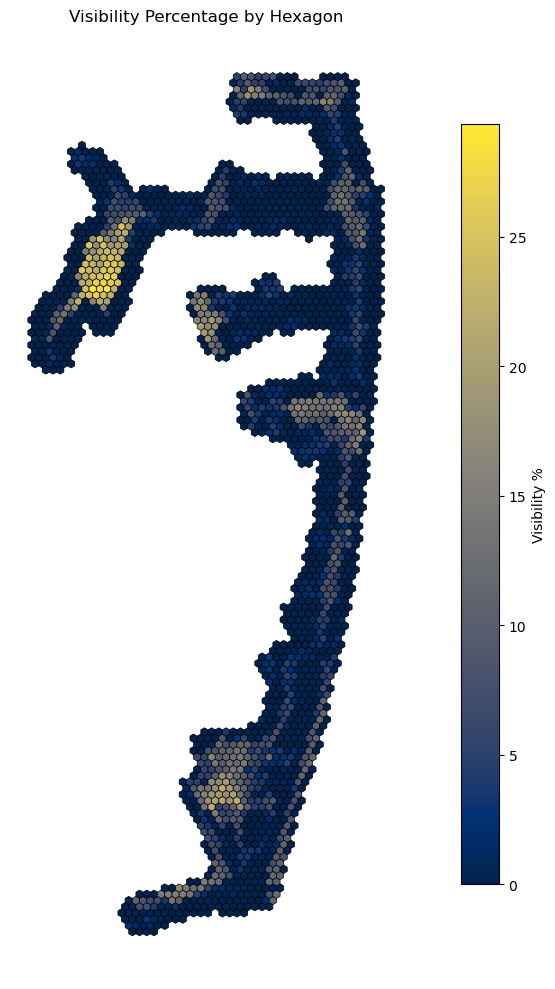

In [35]:
fig, ax = plt.subplots(figsize=(12, 10))
visibility_results_2.plot(column='visibility_pct', 
                          cmap='cividis', 
                          ax=ax,
                          legend=True,
                          edgecolor='k',
                          linewidth=0.5,
                          legend_kwds={'label': 'Visibility %', 'shrink': 0.8})
ax.set_title('Visibility Percentage by Hexagon')
ax.axis('off')
plt.tight_layout()
plt.show()

In [38]:
print(park_2)
park_id = park_2.replace(";", "_")
print(park_id, park_2)

LEEDS_24c20c1a69e8;LEEDS_26c1e2aa11e8
LEEDS_24c20c1a69e8_LEEDS_26c1e2aa11e8 LEEDS_24c20c1a69e8;LEEDS_26c1e2aa11e8


In [ ]:
# # Ensure data is in EPSG:4326 and save
# viz_data = visibility_results_2.drop(columns=['centroids']).to_crs('EPSG:4326')

# # Save to GeoJSON
# output_path = f'../../outputs/{park_id}_visibility_results_hexes.geojson'
# viz_data.to_file(output_path, driver='GeoJSON')